## Logistic Regression

In [20]:
from evaluate_classifier import evaluate_classifier

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [22]:
#importing the cmi_internet_cleaned_dataset
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")



In [23]:
#separating the features from the target variable, sii
X = dataset.drop("sii", axis=1)
y = dataset["sii"]

In [24]:
#show me the distribution of the target variable
print(y.value_counts())


sii
0    5476
1    1444
2     846
3      73
Name: count, dtype: int64


In [25]:
y.value_counts(normalize=True).sort_index()

sii
0    0.698558
1    0.184207
2    0.107922
3    0.009312
Name: proportion, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import StandardScaler

In [27]:
#do the classical train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [28]:
#standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logic Regression Baseline
Here the model will mostly predict class 0 given the heavy imbalanced situation that we observe in the target variable "sii", we are not accounting or modifying anything in the process to consider the imbalance at this stage

In [29]:
from sklearn.linear_model import LogisticRegression


In [30]:
#train the logistic regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [31]:
#predict the test set
y_pred = logistic_model.predict(X_test_scaled)


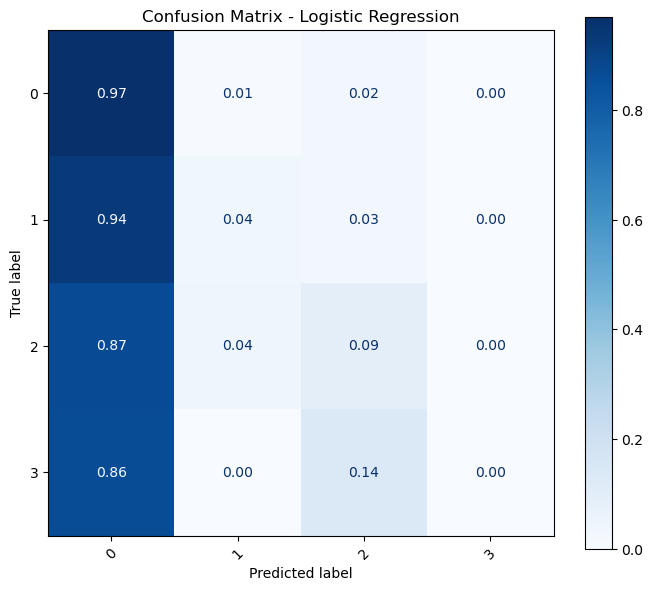

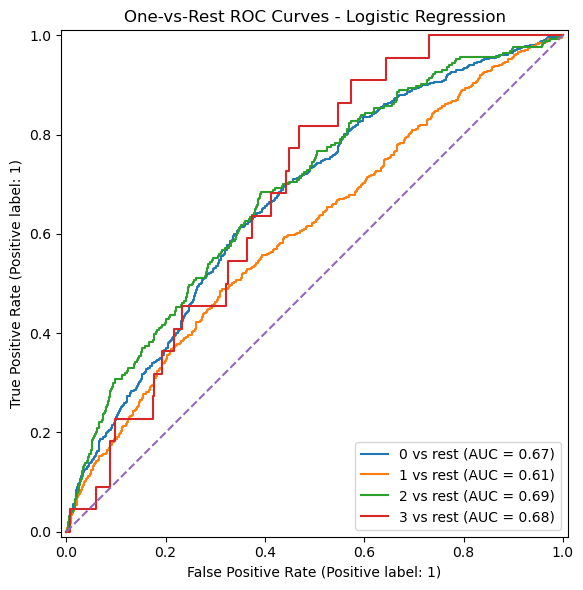

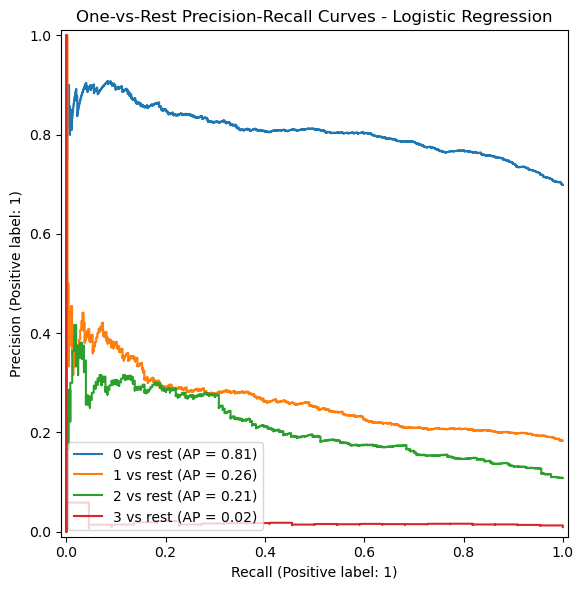


Classification report - Logistic Regression


,precision,recall,f1-score,support
0,0.712243,0.970177,0.821438,1643.000000
1,0.432432,0.036952,0.068085,433.000000
2,0.311688,0.094488,0.145015,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.694728,0.694728,0.694728,0.694728
macro avg,0.364091,0.275404,0.258634,2352.000000
weighted avg,0.610811,0.694728,0.602014,2352.000000


In [32]:
# evaluation of the model
results_logistic, report_logistic = evaluate_classifier(
    model=logistic_model,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression with class_weight = "balanced"
we are changing the way our logistic function is weighting errors, scikit-learn is assigning automatically an heavier weight to rare classes, and a lighter weight to frequent classes

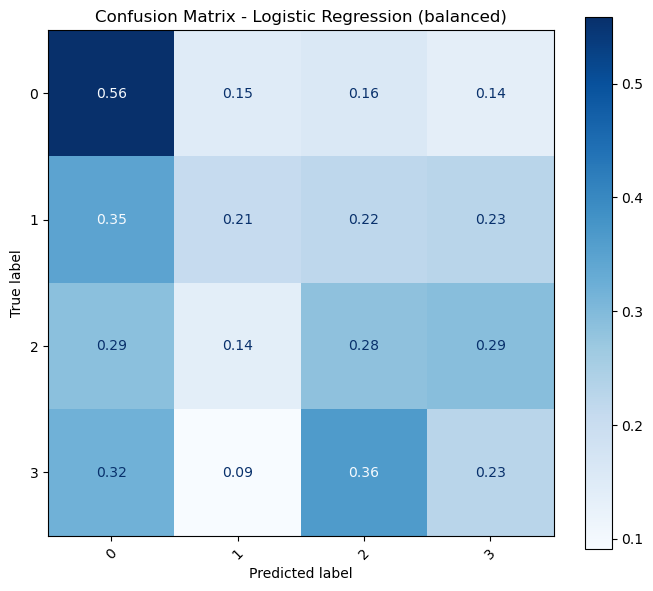

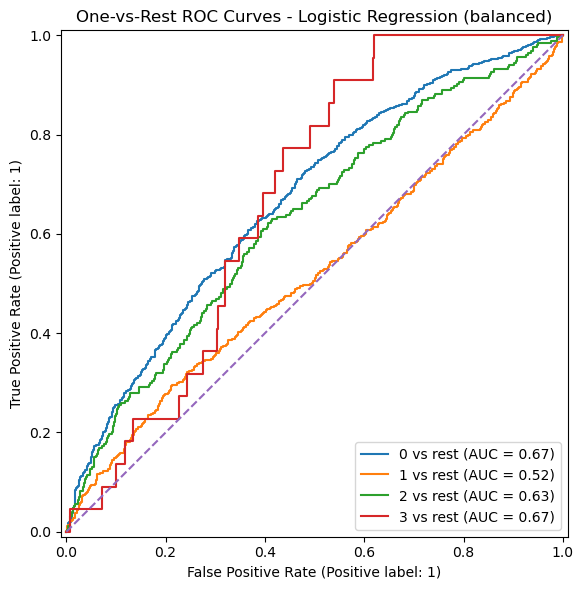

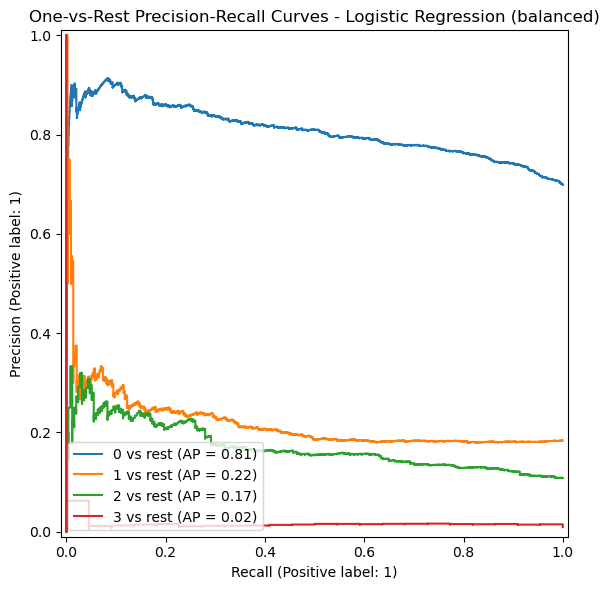


Classification report - Logistic Regression (balanced)


,precision,recall,f1-score,support
0,0.799652,0.558734,0.657829,1643.00000
1,0.245232,0.207852,0.225000,433.00000
2,0.165138,0.283465,0.208696,254.00000
3,0.012469,0.227273,0.023641,22.00000
accuracy,0.461310,0.461310,0.461310,0.46131
macro avg,0.305622,0.319331,0.278791,2352.00000
weighted avg,0.621697,0.461310,0.523710,2352.00000


In [33]:
#now we want to address the fact that the dataset is imbalanced, so we will use the class_weight parameter of the logistic regression model to give more weight to the minority class
logistic_model_balanced = LogisticRegression(random_state=42, class_weight="balanced")
logistic_model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = logistic_model_balanced.predict(X_test_scaled)    
results_logistic_balanced, report_logistic_balanced = evaluate_classifier(
    model=logistic_model_balanced,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (balanced)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression + SMOTE
Here we are not modifying the Logistic Regression, we are modifying the training set, SMOTE is generating new synthetic examples for minority classes

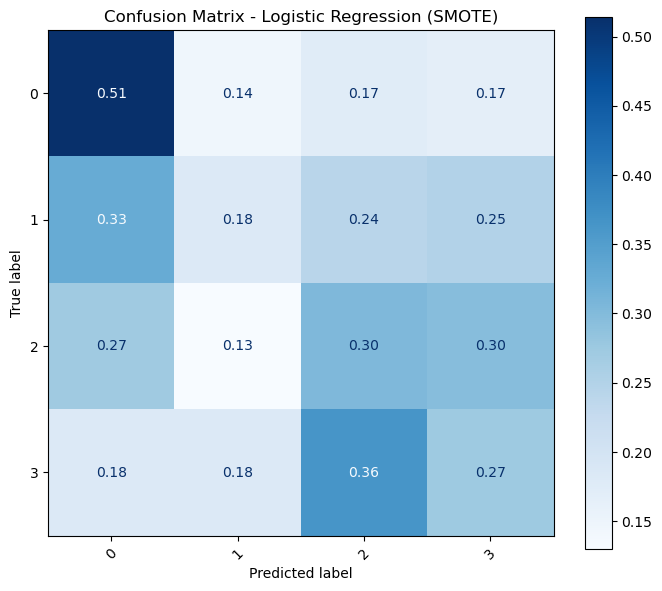

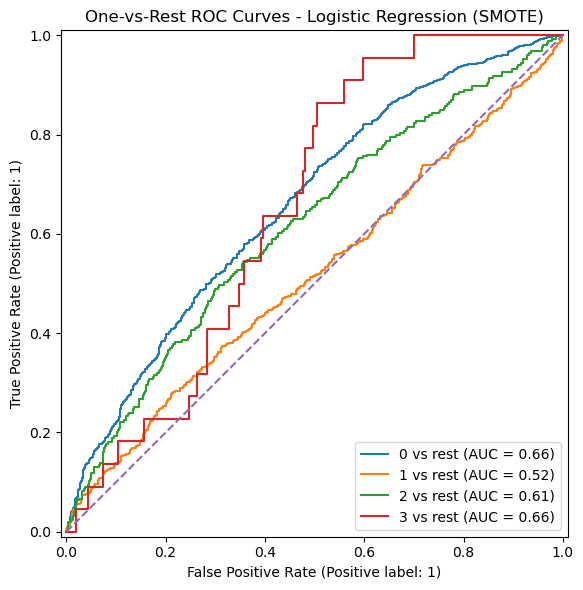

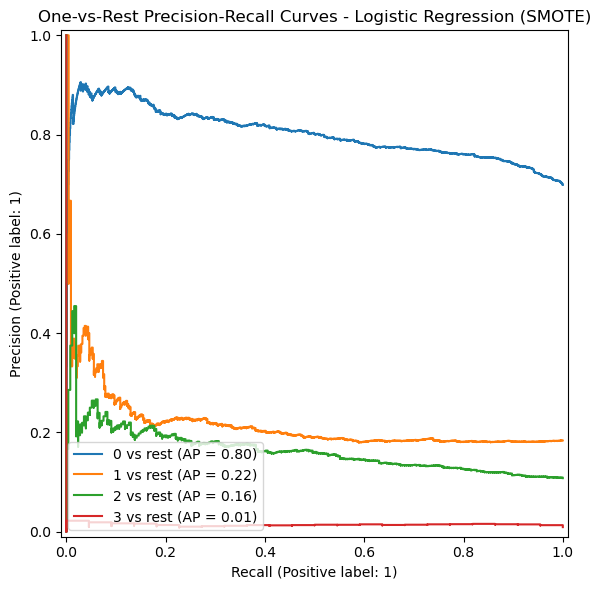


Classification report - Logistic Regression (SMOTE)


,precision,recall,f1-score,support
0,0.797923,0.514303,0.625463,1643.000000
1,0.223796,0.182448,0.201018,433.000000
2,0.161765,0.303150,0.210959,254.000000
3,0.012931,0.272727,0.024691,22.000000
accuracy,0.428146,0.428146,0.428146,0.428146
macro avg,0.299104,0.318157,0.265533,2352.000000
weighted avg,0.616183,0.428146,0.496940,2352.000000


In [34]:
#we try to use another imbalanced classification technique, the SMOTE, to oversample the minority class in the training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
logistic_model_smote = LogisticRegression(random_state=42)
logistic_model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = logistic_model_smote.predict(X_test_scaled)
results_logistic_smote, report_logistic_smote = evaluate_classifier(
    model=logistic_model_smote,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (SMOTE)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression with ADASYIN 
ADASYIN is basically doing something similar to SMOTE, but it is more adaptive

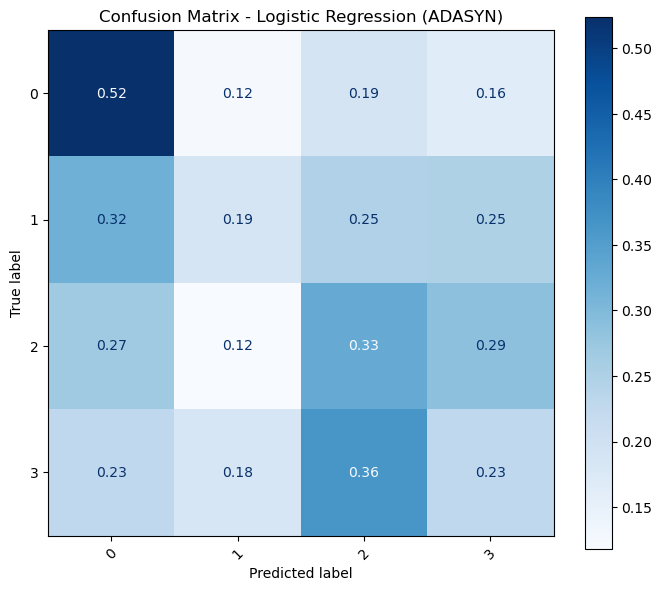

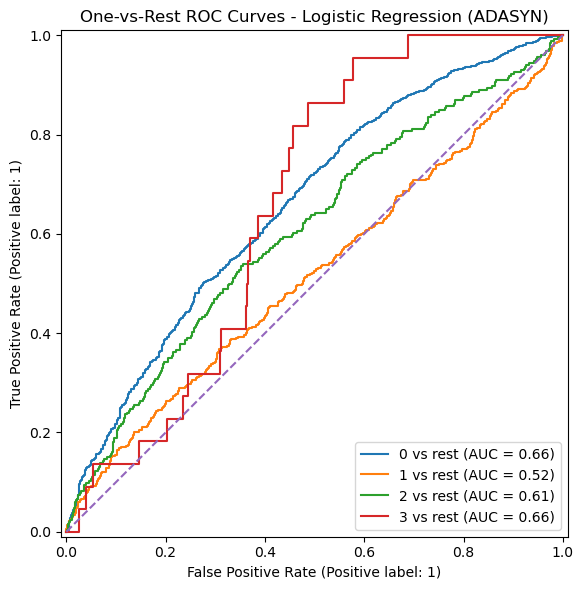

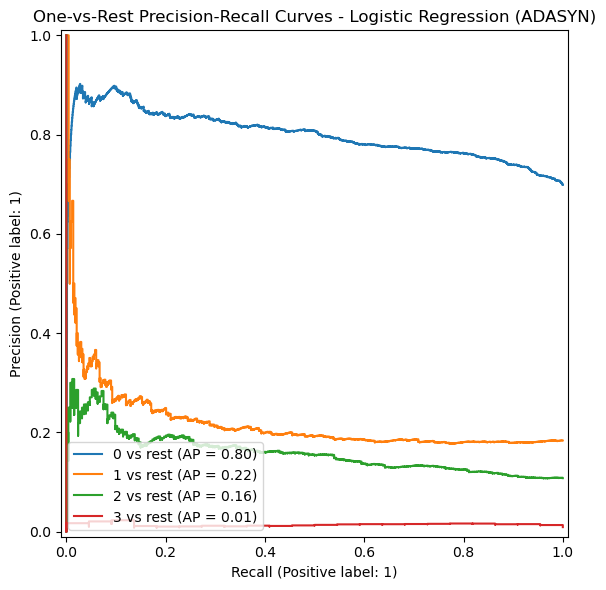


Classification report - Logistic Regression (ADASYN)


,precision,recall,f1-score,support
0,0.803922,0.524041,0.634488,1643.000000
1,0.256329,0.187067,0.216288,433.000000
2,0.163386,0.326772,0.217848,254.000000
3,0.010941,0.227273,0.020877,22.000000
accuracy,0.437925,0.437925,0.437925,0.437925
macro avg,0.308644,0.316288,0.272375,2352.000000
weighted avg,0.626520,0.437925,0.506764,2352.000000


In [35]:
#now we can use ADASYN, another imbalanced classification technique, to oversample the minority class in the training set
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
logistic_model_adasyn = LogisticRegression(random_state=42)
logistic_model_adasyn.fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = logistic_model_adasyn.predict(X_test_scaled)
results_logistic_adasyn, report_logistic_adasyn = evaluate_classifier(
    model=logistic_model_adasyn,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (ADASYN)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression with SMOTE Tomek Link

Original training distribution:
sii
0    3833
1    1011
2     592
3      51
Name: count, dtype: int64

After SMOTE + Tomek distribution:
sii
0    3824
1    3824
2    3833
3    3833
Name: count, dtype: int64


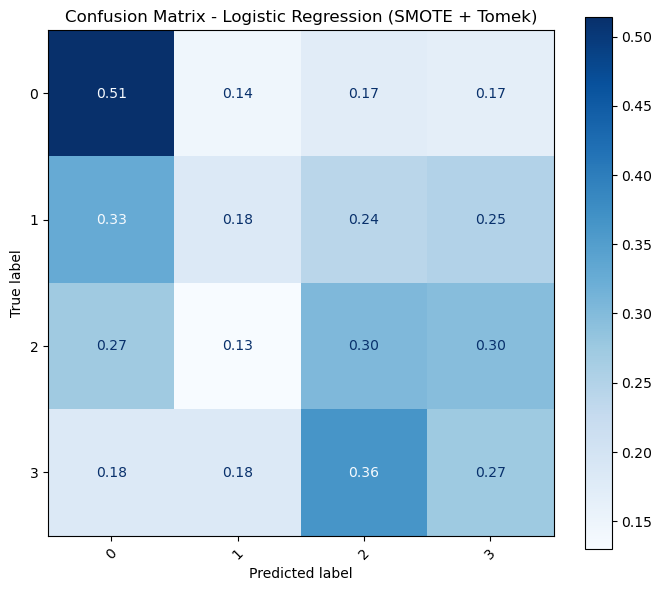

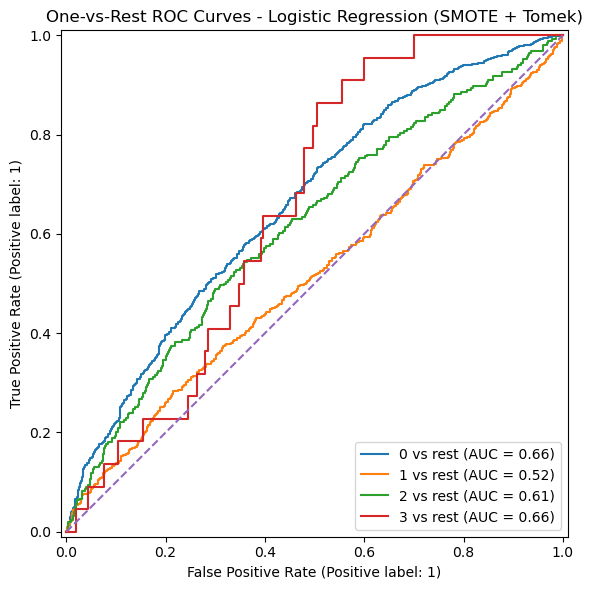

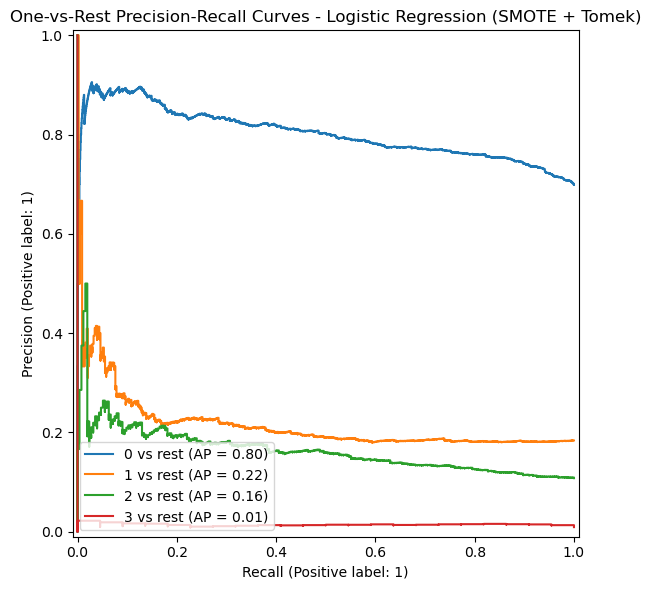


Classification report - Logistic Regression (SMOTE + Tomek)


,precision,recall,f1-score,support
0,0.797170,0.514303,0.625231,1643.000000
1,0.223164,0.182448,0.200762,433.000000
2,0.162447,0.303150,0.211538,254.000000
3,0.012931,0.272727,0.024691,22.000000
accuracy,0.428146,0.428146,0.428146,0.428146
macro avg,0.298928,0.318157,0.265556,2352.000000
weighted avg,0.615615,0.428146,0.496794,2352.000000


In [37]:
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression

# SMOTE + Tomek Links
smote_tomek = SMOTETomek(random_state=42)

X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE + Tomek distribution:")
print(pd.Series(y_train_smote_tomek).value_counts().sort_index())

# Train Logistic Regression
logistic_model_smote_tomek = LogisticRegression(
    random_state=42,
    max_iter=3000
)

logistic_model_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek)

# Evaluate
results_logistic_smote_tomek, report_logistic_smote_tomek = evaluate_classifier(
    model=logistic_model_smote_tomek,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (SMOTE + Tomek)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression with Random Undersampling

Original training distribution:
sii
0    3833
1    1011
2     592
3      51
Name: count, dtype: int64

After Random Undersampling distribution:
sii
0    51
1    51
2    51
3    51
Name: count, dtype: int64


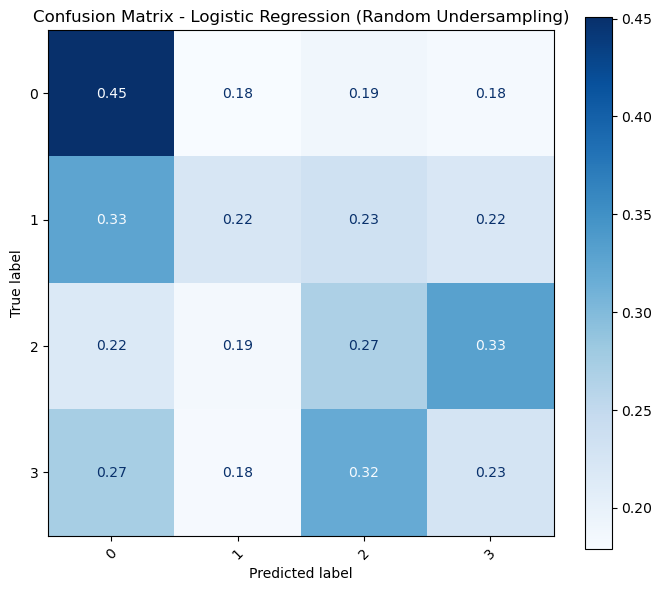

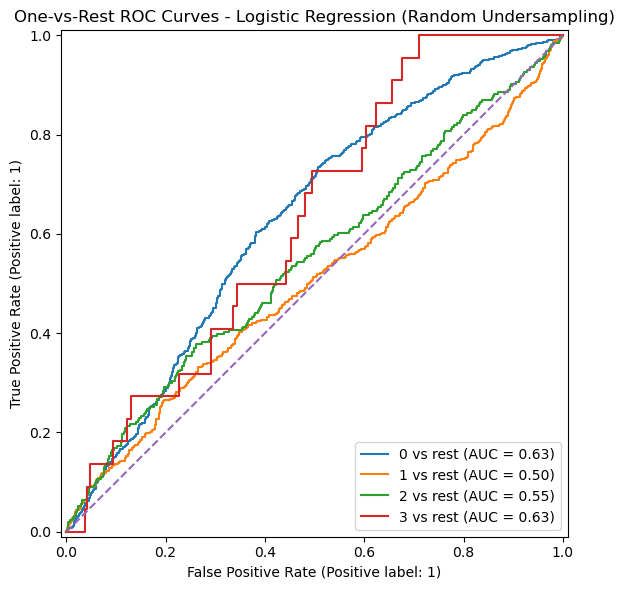

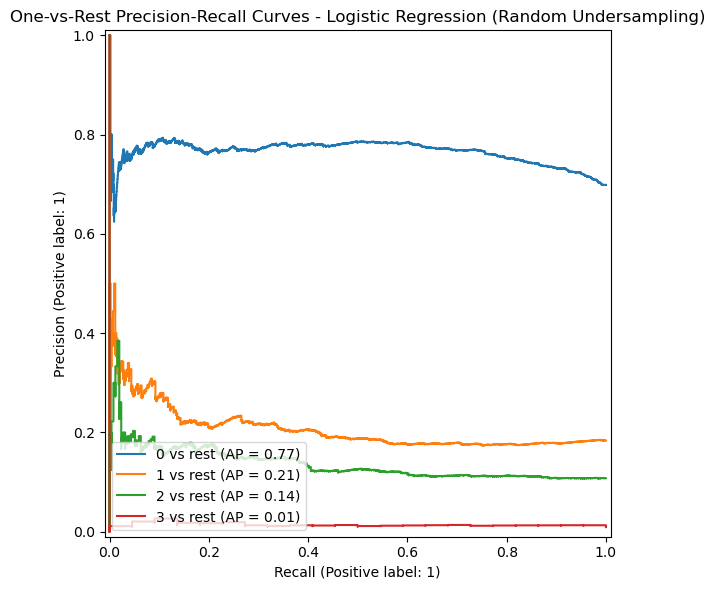


Classification report - Logistic Regression (Random Undersampling)


,precision,recall,f1-score,support
0,0.785790,0.451004,0.573086,1643.000000
1,0.217687,0.221709,0.219680,433.000000
2,0.140496,0.267717,0.184282,254.000000
3,0.010331,0.227273,0.019763,22.000000
accuracy,0.386905,0.386905,0.386905,0.386905
macro avg,0.288576,0.291926,0.249203,2352.000000
weighted avg,0.604262,0.386905,0.460860,2352.000000


In [38]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(y_train.value_counts().sort_index())

print("\nAfter Random Undersampling distribution:")
print(pd.Series(y_train_rus).value_counts().sort_index())

logistic_model_rus = LogisticRegression(
    random_state=42,
    max_iter=3000
)

logistic_model_rus.fit(X_train_rus, y_train_rus)

results_logistic_rus, report_logistic_rus = evaluate_classifier(
    model=logistic_model_rus,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (Random Undersampling)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Logistic Regression with only Tomek Link

Original training distribution:
sii
0    3833
1    1011
2     592
3      51
Name: count, dtype: int64

After Tomek Links distribution:
sii
0    3634
1     839
2     507
3      51
Name: count, dtype: int64


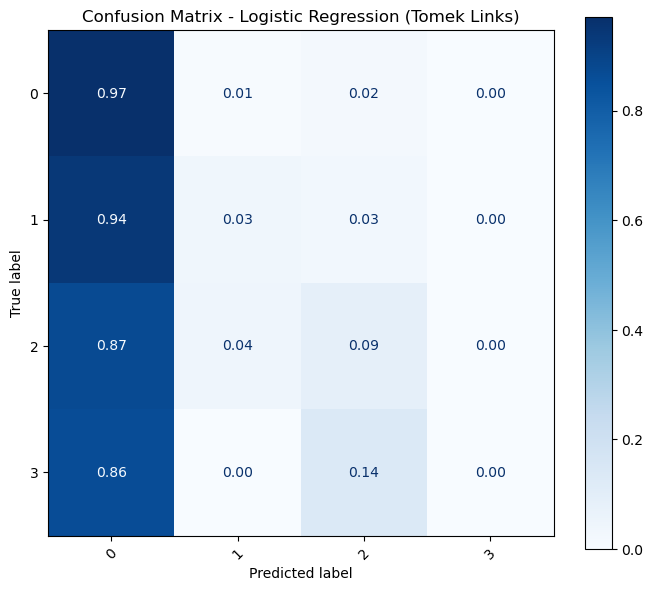

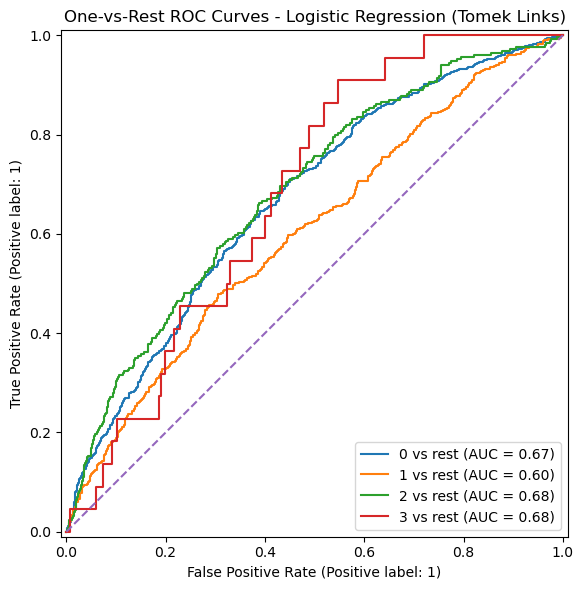

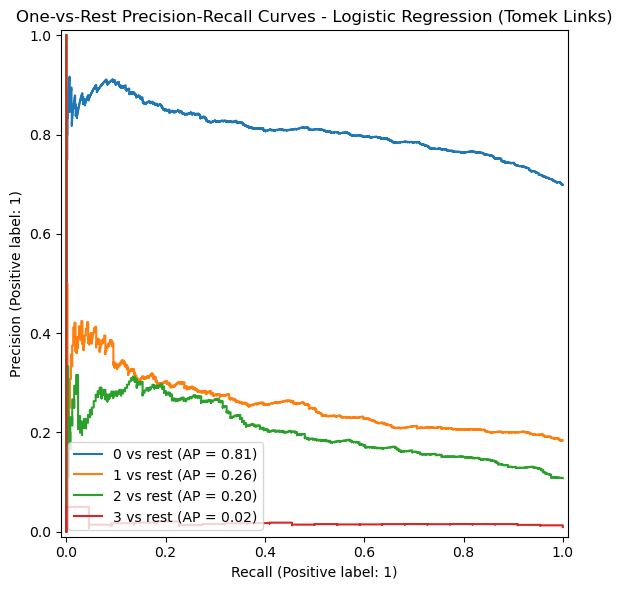


Classification report - Logistic Regression (Tomek Links)


,precision,recall,f1-score,support
0,0.711864,0.971394,0.821622,1643.000000
1,0.394737,0.034642,0.063694,433.000000
2,0.305556,0.086614,0.134969,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.694303,0.694303,0.694303,0.694303
macro avg,0.353039,0.273162,0.255071,2352.000000
weighted avg,0.602944,0.694303,0.600249,2352.000000


In [39]:
from imblearn.under_sampling import TomekLinks
from sklearn.linear_model import LogisticRegression

tomek = TomekLinks()

X_train_tomek, y_train_tomek = tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(y_train.value_counts().sort_index())

print("\nAfter Tomek Links distribution:")
print(pd.Series(y_train_tomek).value_counts().sort_index())

logistic_model_tomek = LogisticRegression(
    random_state=42,
    max_iter=3000
)

logistic_model_tomek.fit(X_train_tomek, y_train_tomek)

results_logistic_tomek, report_logistic_tomek = evaluate_classifier(
    model=logistic_model_tomek,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression (Tomek Links)",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

## Comparing Results of Different Approaches

In [40]:
logistic_comparison = pd.DataFrame([
    results_logistic,
    results_logistic_balanced,
    results_logistic_smote,
    results_logistic_adasyn,
    results_logistic_smote_tomek,
    results_logistic_rus
])

logistic_comparison.sort_values("f1_macro", ascending=False)

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,roc_auc_ovr_weighted,roc_auc_ovr_macro
1,Logistic Regression (balanced),0.461310,0.319331,0.621697,0.461310,0.523710,0.305622,0.319331,0.278791,0.635762,0.622122
3,Logistic Regression (ADASYN),0.437925,0.316288,0.626520,0.437925,0.506764,0.308644,0.316288,0.272375,0.627044,0.610341
4,Logistic Regression (SMOTE + Tomek),0.428146,0.318157,0.615615,0.428146,0.496794,0.298928,0.318157,0.265556,0.628809,0.612067
2,Logistic Regression (SMOTE),0.428146,0.318157,0.616183,0.428146,0.496940,0.299104,0.318157,0.265533,0.628847,0.612028
0,Logistic Regression,0.694728,0.275404,0.610811,0.694728,0.602014,0.364091,0.275404,0.258634,0.658959,0.660499
5,Logistic Regression (Random Undersampling),0.386905,0.291926,0.604262,0.386905,0.460860,0.288576,0.291926,0.249203,0.597827,0.578055


## Hyper Parameters Tuning

In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid_logistic = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"],
    "penalty": ["l2"],
    "max_iter": [3000]
}

logistic_base = LogisticRegression(
    random_state=42
)

grid_logistic = GridSearchCV(
    estimator=logistic_base,
    param_grid=param_grid_logistic,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_logistic.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_logistic.best_params_)

print("\nBest CV F1 macro:")
print(grid_logistic.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV F1 macro:
0.3007561748704101


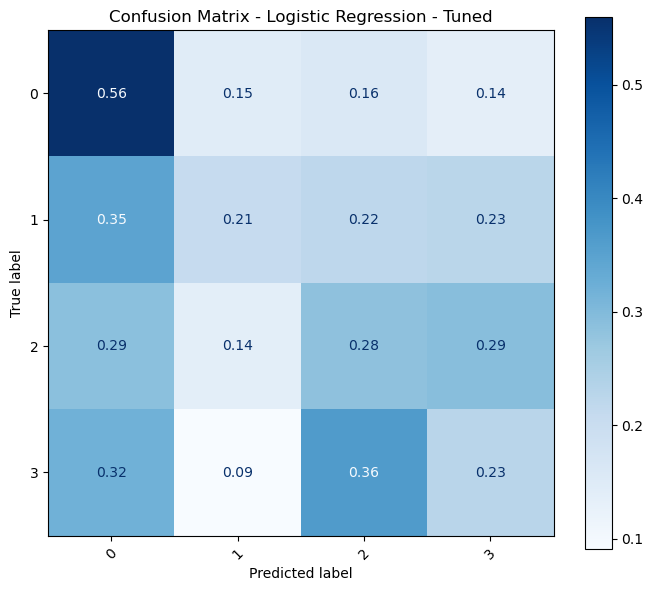

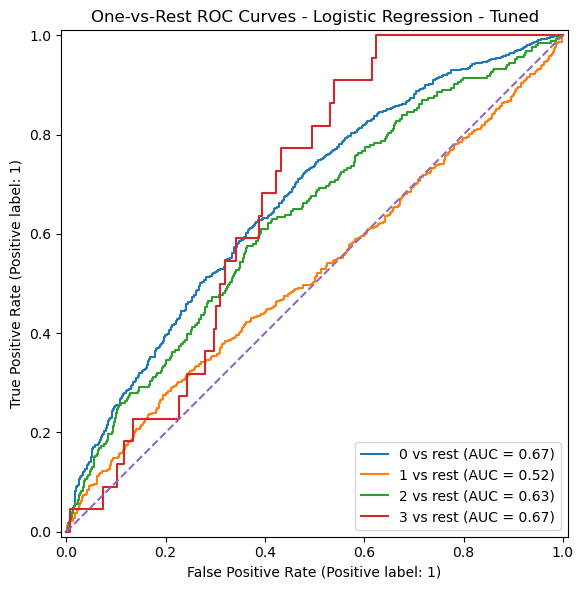

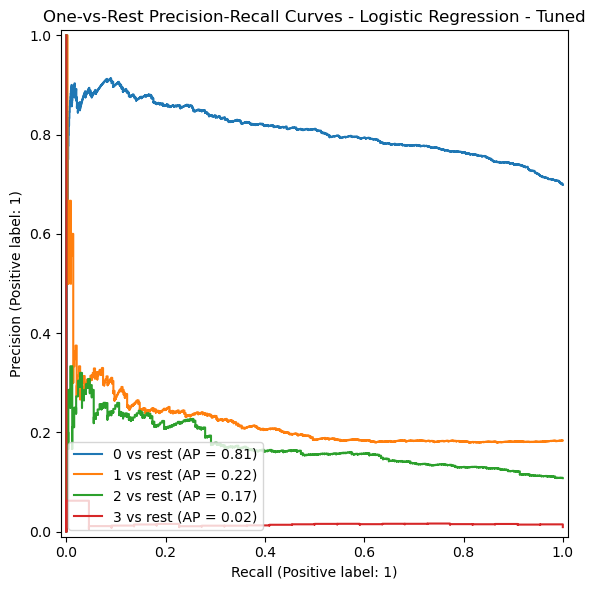


Classification report - Logistic Regression - Tuned


,precision,recall,f1-score,support
0,0.800000,0.559951,0.658790,1643.00000
1,0.245902,0.207852,0.225282,433.00000
2,0.164760,0.283465,0.208394,254.00000
3,0.012531,0.227273,0.023753,22.00000
accuracy,0.462160,0.462160,0.462160,0.46216
macro avg,0.305798,0.319635,0.279055,2352.00000
weighted avg,0.622024,0.462160,0.524402,2352.00000


In [42]:
best_logistic = grid_logistic.best_estimator_

results_logistic_tuned, report_logistic_tuned = evaluate_classifier(
    model=best_logistic,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression - Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

In [43]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipe_smote_tomek_logistic = Pipeline([
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("clf", LogisticRegression(random_state=42, max_iter=3000))
])

param_grid_smote_tomek_logistic = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

grid_smote_tomek_logistic = GridSearchCV(
    estimator=pipe_smote_tomek_logistic,
    param_grid=param_grid_smote_tomek_logistic,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_smote_tomek_logistic.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_smote_tomek_logistic.best_params_)

print("\nBest CV F1 macro:")
print(grid_smote_tomek_logistic.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters:
{'clf__C': 0.01, 'clf__class_weight': 'balanced'}

Best CV F1 macro:
0.2963784607077095


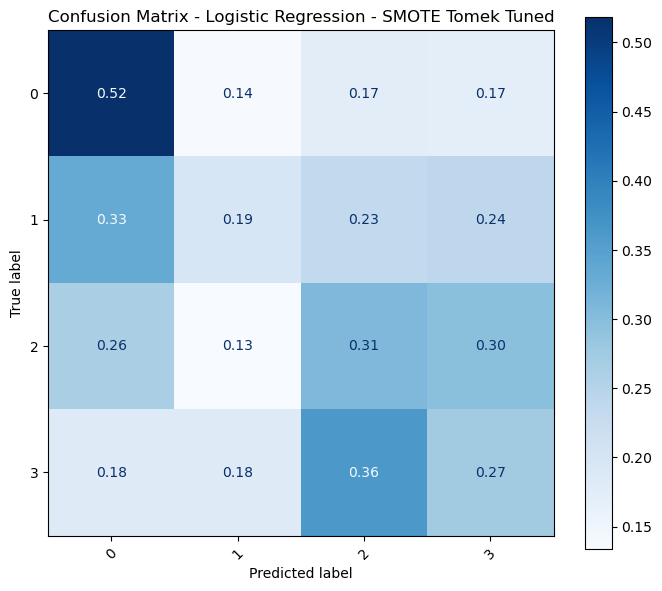

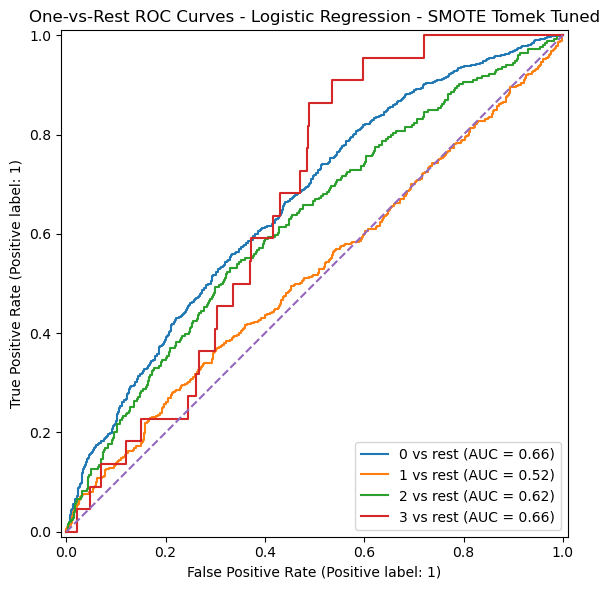

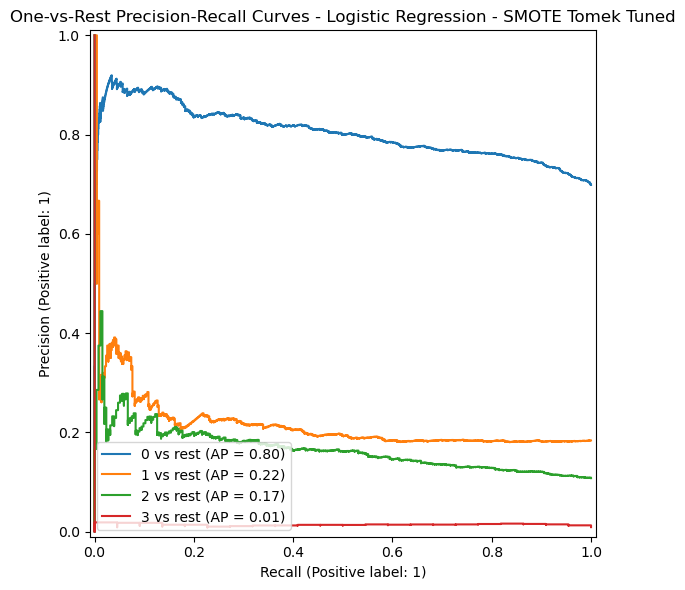


Classification report - Logistic Regression - SMOTE Tomek Tuned


,precision,recall,f1-score,support
0,0.798500,0.518564,0.628782,1643.000000
1,0.242775,0.193995,0.215661,433.000000
2,0.165254,0.307087,0.214876,254.000000
3,0.012848,0.272727,0.024540,22.000000
accuracy,0.433673,0.433673,0.433673,0.433673
macro avg,0.304844,0.323093,0.270965,2352.000000
weighted avg,0.620457,0.433673,0.502376,2352.000000


In [44]:
best_smote_tomek_logistic = grid_smote_tomek_logistic.best_estimator_

results_logistic_smote_tomek_tuned, report_logistic_smote_tomek_tuned = evaluate_classifier(
    model=best_smote_tomek_logistic,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression - SMOTE Tomek Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

In [45]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipe_smote_logistic = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(random_state=42, max_iter=3000))
])

param_grid_smote_logistic = {
    "smote__k_neighbors": [3, 5],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

grid_smote_logistic = GridSearchCV(
    estimator=pipe_smote_logistic,
    param_grid=param_grid_smote_logistic,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_smote_logistic.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_smote_logistic.best_params_)

print("\nBest CV F1 macro:")
print(grid_smote_logistic.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'clf__C': 0.01, 'clf__class_weight': None, 'smote__k_neighbors': 5}

Best CV F1 macro:
0.29619566042855305


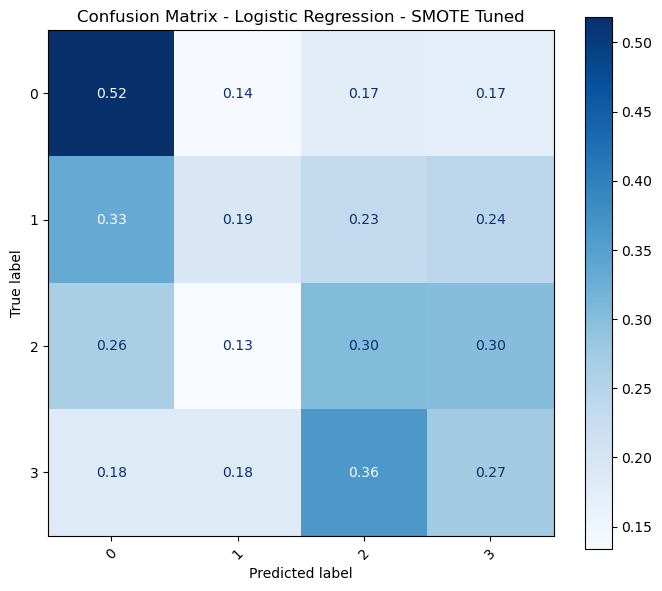

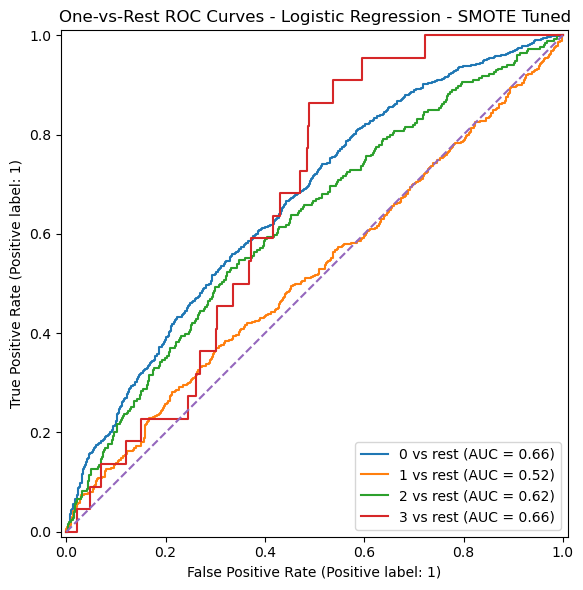

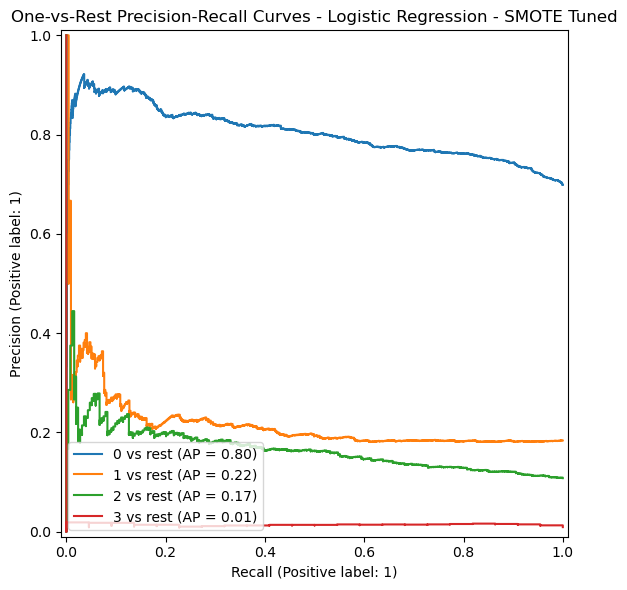


Classification report - Logistic Regression - SMOTE Tuned


,precision,recall,f1-score,support
0,0.798500,0.518564,0.628782,1643.000000
1,0.241279,0.191686,0.213642,433.000000
2,0.163136,0.303150,0.212121,254.000000
3,0.012793,0.272727,0.024440,22.000000
accuracy,0.432823,0.432823,0.432823,0.432823
macro avg,0.303927,0.321532,0.269746,2352.000000
weighted avg,0.619952,0.432823,0.501706,2352.000000


In [46]:
best_smote_logistic = grid_smote_logistic.best_estimator_

results_logistic_smote_tuned, report_logistic_smote_tuned = evaluate_classifier(
    model=best_smote_logistic,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression - SMOTE Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=True,
    plot_pr=True,
    normalize_cm="true"
)

In [47]:
logistic_results_table = pd.DataFrame([
    results_logistic,
    results_logistic_balanced,
    results_logistic_smote,
    results_logistic_adasyn,
    results_logistic_tuned,
    results_logistic_smote_tuned,
    results_logistic_smote_tomek_tuned
])

logistic_results_table.sort_values("f1_macro", ascending=False)

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,roc_auc_ovr_weighted,roc_auc_ovr_macro
4,Logistic Regression - Tuned,0.462160,0.319635,0.622024,0.462160,0.524402,0.305798,0.319635,0.279055,0.636079,0.622771
1,Logistic Regression (balanced),0.461310,0.319331,0.621697,0.461310,0.523710,0.305622,0.319331,0.278791,0.635762,0.622122
3,Logistic Regression (ADASYN),0.437925,0.316288,0.626520,0.437925,0.506764,0.308644,0.316288,0.272375,0.627044,0.610341
6,Logistic Regression - SMOTE Tomek Tuned,0.433673,0.323093,0.620457,0.433673,0.502376,0.304844,0.323093,0.270965,0.630675,0.615531
5,Logistic Regression - SMOTE Tuned,0.432823,0.321532,0.619952,0.432823,0.501706,0.303927,0.321532,0.269746,0.630698,0.615464
2,Logistic Regression (SMOTE),0.428146,0.318157,0.616183,0.428146,0.496940,0.299104,0.318157,0.265533,0.628847,0.612028
0,Logistic Regression,0.694728,0.275404,0.610811,0.694728,0.602014,0.364091,0.275404,0.258634,0.658959,0.660499
